In [17]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import emcee
import ultranest

In [18]:
# Le larghezze esatte derivate dalla stringa Fortran
widths = [1, 3, 5, 5, 5, 1, 3, 4, 1, 14, 12, 13, 1, 10, 1, 2, 13, 11, 1, 3, 1, 13, 12]

nomi_colonne = [
    'cc', 'NZ', 'N', 'Z', 'A', 'skip_1', 'el', 'o', 'skip_2', 
    'mass_excess', 'mass_unc', 'binding', 'skip_3', 'binding_unc', 'skip_4', 
    'B', 'beta_decay', 'beta_unc', 'skip_5', 'atomic_mass_int', 'skip_6', 
    'atomic_mass_dec', 'atomic_mass_unc'
]

# Leggiamo il file (skiprows=39 dovrebbe saltare esattamente tutta l'intestazione testuale)
df = pd.read_fwf('mass_1.mas20.txt', widths=widths, names=nomi_colonne, skiprows=38)

# Rimuoviamo le colonne vuote usate come separatori
df = df.drop(columns=[col for col in df.columns if 'skip' in col])

# se ho il # alla fine del numero in BE, significa che è un numero approssimato, quindi elimino la riga
df = df.replace(r'(\d+)#', np.nan, regex=True)

# Sostituiamo gli asterischi '*' con NaN (Not a Number, lo standard per i dati mancanti)
df = df.replace(r'^\s*\*\s*$', np.nan, regex=True)

df = df.dropna(subset=['binding'])

# Forziamo la conversione in numeri decimali (float) per le colonne che contenevano valori
colonne_numeriche = [
    'mass_excess', 'mass_unc', 'binding', 'binding_unc', 
    'beta_decay', 'beta_unc', 'atomic_mass_dec', 'atomic_mass_unc'
]

for col in colonne_numeriche:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Risultato finale
print(df.head())

    cc  NZ  N  Z  A  el    o   mass_excess    mass_unc     binding  \
0  0.0   0  1  1  2   H  NaN  13135.722895    0.000015  1112.28310   
1  0.0   1  2  1  3   H  NaN  14949.810900    0.000080  2827.26540   
2  NaN  -1  1  2  3  He  NaN  14931.218880    0.000060  2572.68044   
4  0.0   2  3  1  4   H   -n  24621.129000  100.000000  1720.44910   
5  NaN   0  2  2  4  He  NaN   2424.915870    0.000150  7073.91560   

   binding_unc   B   beta_decay   beta_unc  atomic_mass_int  atomic_mass_dec  \
0      0.00020  B-          NaN        NaN                2     14101.777844   
1      0.00030  B-     18.59202    0.00006                3     16049.281320   
2      0.00015  B-          NaN        NaN                3     16029.321970   
4     25.00000  B-  22196.21310  100.00000                4     26431.867000   
5      0.00020  B- -22898.27400  212.13200                4      2603.254130   

   atomic_mass_unc  
0         0.000015  
1         0.000080  
2         0.000060  
4       107.35

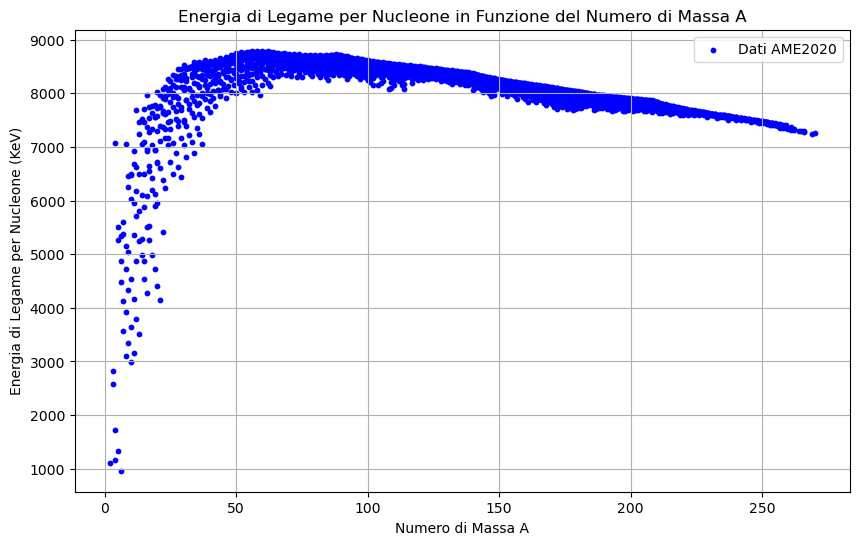

In [19]:
# grafico di BE in funzione di A
plt.figure(figsize=(10, 6))
plt.scatter(df['A'], df['binding'], s=10, color='blue', label='Dati AME2020')
plt.xlabel('Numero di Massa A')
plt.ylabel('Energia di Legame per Nucleone (KeV)')
plt.title('Energia di Legame per Nucleone in Funzione del Numero di Massa A')
plt.legend()
plt.grid()
plt.show()

In [20]:
# inferenza bayesiana con ultranest
def prior(cube):
    # cube è un array di valori tra 0 e 1, che dobbiamo trasformare nei nostri parametri
    a = 10 * cube[0] * 10 
    b = 10.0 * cube[1] * 15 
    c = cube[2] * 2 
    d =  10 * cube[3] * 25 
    sigma_th = cube[4] * 10
    return [a, b, c, d, sigma_th]

def model(A, Z, N, a, b, c, d):
    return a * A - b * A**(2/3) - c*(Z* (Z - 1) / (A**(1/3))) - d * (N-Z)**2 / A

def log_likelihood(params):
    a, b, c, d, sigma_th = params
    A = df['A'].values
    Z = df['Z'].values
    N = df['N'].values
    BE_obs = (df['binding'].values /1000)*A  # Convertiamo da KeV a MeV
    BE_model = model(A, Z, N, a, b, c, d)
    sigma_exp = (df['binding_unc'].values / 1000) * A  # in MeV
    sigma_tot = np.sqrt(sigma_exp**2 + sigma_th**2)
    
    # Log-likelihood usando l'incertezza totale
    logL = -0.5 * np.sum(((BE_obs - BE_model) / sigma_tot)**2 + np.log(2 * np.pi * sigma_tot**2))
    return logL

In [21]:
#run ultranest
sampler = ultranest.ReactiveNestedSampler(['a', 'b', 'c', 'd', 'sigma_th'], log_likelihood, prior)
result = sampler.run(min_num_live_points=600, dKL=np.inf, min_ess=200)
print(result)

[ultranest] Sampling 600 live points from prior ...


[ultranest] Explored until L=-7e+03  993.81 [-6995.1114..-6995.1084]*| it/evals=22780/67302 eff=34.1519% N=600             0  
[ultranest] Likelihood function evaluations: 67302
[ultranest]   logZ = -7031 +- 0.1603
[ultranest] Effective samples strategy satisfied (ESS = 2660.0, need >200)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.04 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.28, need <0.5)
[ultranest]   logZ error budget: single: 0.24 bs:0.16 tail:0.23 total:0.28 required:<0.50
[ultranest] done iterating.
{'niter': 23381, 'logz': np.float64(-7031.298572842387), 'logzerr': np.float64(0.30496932985558384), 'logz_bs': np.float64(-7031.345474484232), 'logz_single': np.float64(-7031.298572842387), 'logzerr_tail': np.float64(0.23173427860274387), 'logzerr_bs': np.float64(0.19825618848608428), 'ess': np.float64(2660.0157816384194), 'H': np.float64(34.86461164730281), 'Herr': np.float64(0.1561531683319203), 'posterior': {'mean

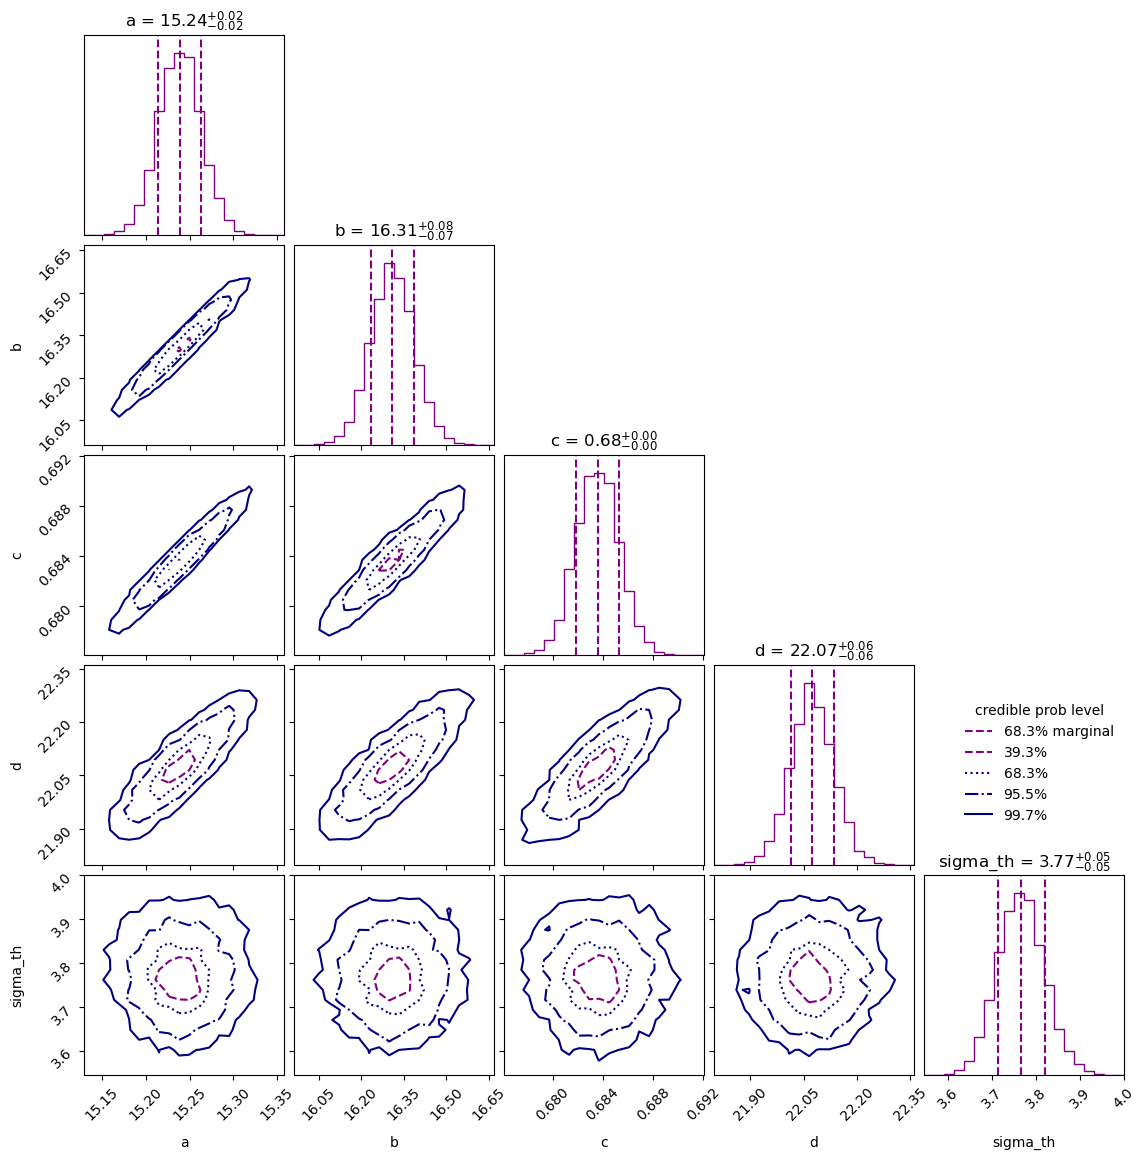

In [22]:
cornerplot = sampler.plot_corner()

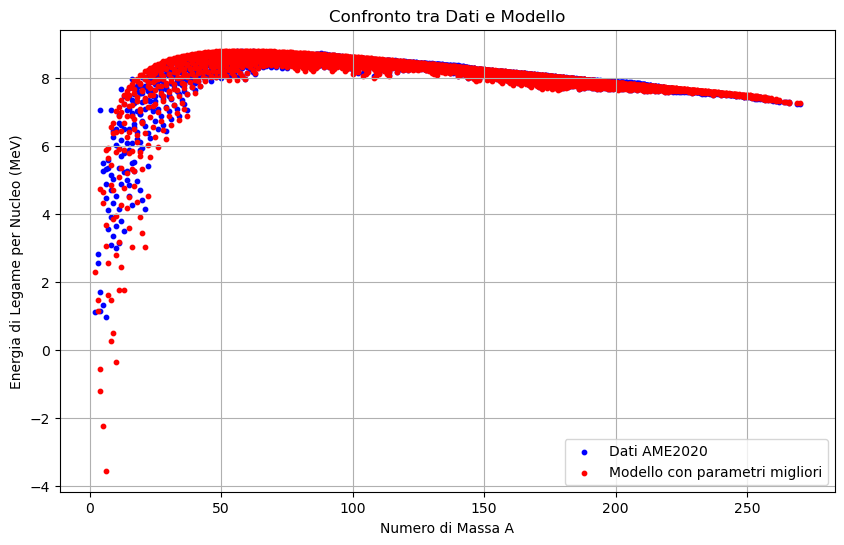

In [23]:
# calcolo il BE con i parametri migliori per ogni nucleo e confronto con i dati
a_best, b_best, c_best, d_best, sigma_th_best = result['posterior']['mean']
A = df['A'].values
Z = df['Z'].values
N = df['N'].values
BE_obs = (df['binding'].values /1000) # Convertiamo da KeV a MeV
BE_model = model(A, Z, N, a_best, b_best, c_best, d_best)/A   
plt.figure(figsize=(10, 6))
plt.scatter(A, BE_obs, s=10, color='blue', label='Dati AME2020')
plt.scatter(A, BE_model, s=10, color='red', label='Modello con parametri migliori')
plt.xlabel('Numero di Massa A')
plt.ylabel('Energia di Legame per Nucleo (MeV)')
plt.title('Confronto tra Dati e Modello')
plt.legend()
plt.grid()
plt.show()

In [24]:
def prior_delta(cube):
    a = 10 * cube[0] * 10 
    b = 10.0 * cube[1] * 15 
    c = cube[2] * 2 
    d =  10 * cube[3] * 25 
    delta_0 = cube[4] * 30  
    sigma_th = cube[5] * 10
    
    return [a, b, c, d, delta_0, sigma_th]

def model_delta(A, Z, N, a, b, c, d, delta_0):
    delta = np.zeros_like(A, dtype=float)
    
    # Maschere booleane per pari-pari e dispari-dispari
    pari_pari = (N % 2 == 0) & (Z % 2 == 0)
    dispari_dispari = (N % 2 == 1) & (Z % 2 == 1)
    pari_dispari = (N%2 ==0) & (Z%2 == 1) | (N%2 == 1) & (Z%2 == 0)
    
    # Calcolo massivo
    delta_term = delta_0 / A**(3/4)
    
    # Assegnazione
    delta[pari_pari] = delta_term[pari_pari]
    delta[dispari_dispari] = -delta_term[dispari_dispari]
    delta[pari_dispari] = 0
    
    return a * A - b * A**(2/3) - c*(Z* (Z - 1) / (A**(1/3))) - d * (N-Z)**2 / A + delta 

def log_likelihood_delta(params):
    a, b, c, d, delta_0, sigma_th = params
    A = df['A'].values
    Z = df['Z'].values
    N = df['N'].values
    BE_obs = (df['binding'].values /1000)*A  # Convertiamo da KeV a MeV
    BE_model = model_delta(A, Z, N, a, b, c, d, delta_0)
    sigma_exp = (df['binding_unc'].values / 1000) * A  # in MeV
    sigma_tot = np.sqrt(sigma_exp**2 + sigma_th**2)
    
    # Log-likelihood usando l'incertezza totale
    logL = -0.5 * np.sum(((BE_obs - BE_model) / sigma_tot)**2 + np.log(2 * np.pi * sigma_tot**2))
    return logL

In [25]:
#run ultranest
sampler_delta = ultranest.ReactiveNestedSampler(['a', 'b', 'c', 'd',  'delta_0', 'sigma_th'], log_likelihood_delta, prior_delta)
result_delta = sampler_delta.run(min_num_live_points=400, dKL=np.inf, min_ess=100)
print(result_delta)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+03  942.22 [-6944.2300..-6944.2292]*| it/evals=15570/62364 eff=25.1275% N=400     0  0   0   
[ultranest] Likelihood function evaluations: 62364
[ultranest]   logZ = -6982 +- 0.188
[ultranest] Effective samples strategy satisfied (ESS = 1327.6, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.15 to 0.55, need <0.5)
[ultranest]   logZ error budget: single: 0.30 bs:0.19 tail:0.33 total:0.38 required:<0.50
[ultranest] done iterating.
{'niter': 15971, 'logz': np.float64(-6981.519747315438), 'logzerr': np.float64(0.6430323693797028), 'logz_bs': np.float64(-6981.526019042539), 'logz_single': np.float64(-6981.519747315438), 'logzerr_tail': np.float64(0.32703607303847093), 'logzerr_bs': np.float64(0.5536587712676919), 'ess': np.float64(1327.613044398029), 'H': np.float64(36.02160383101727), 'Herr': np.float64(0.181922107584

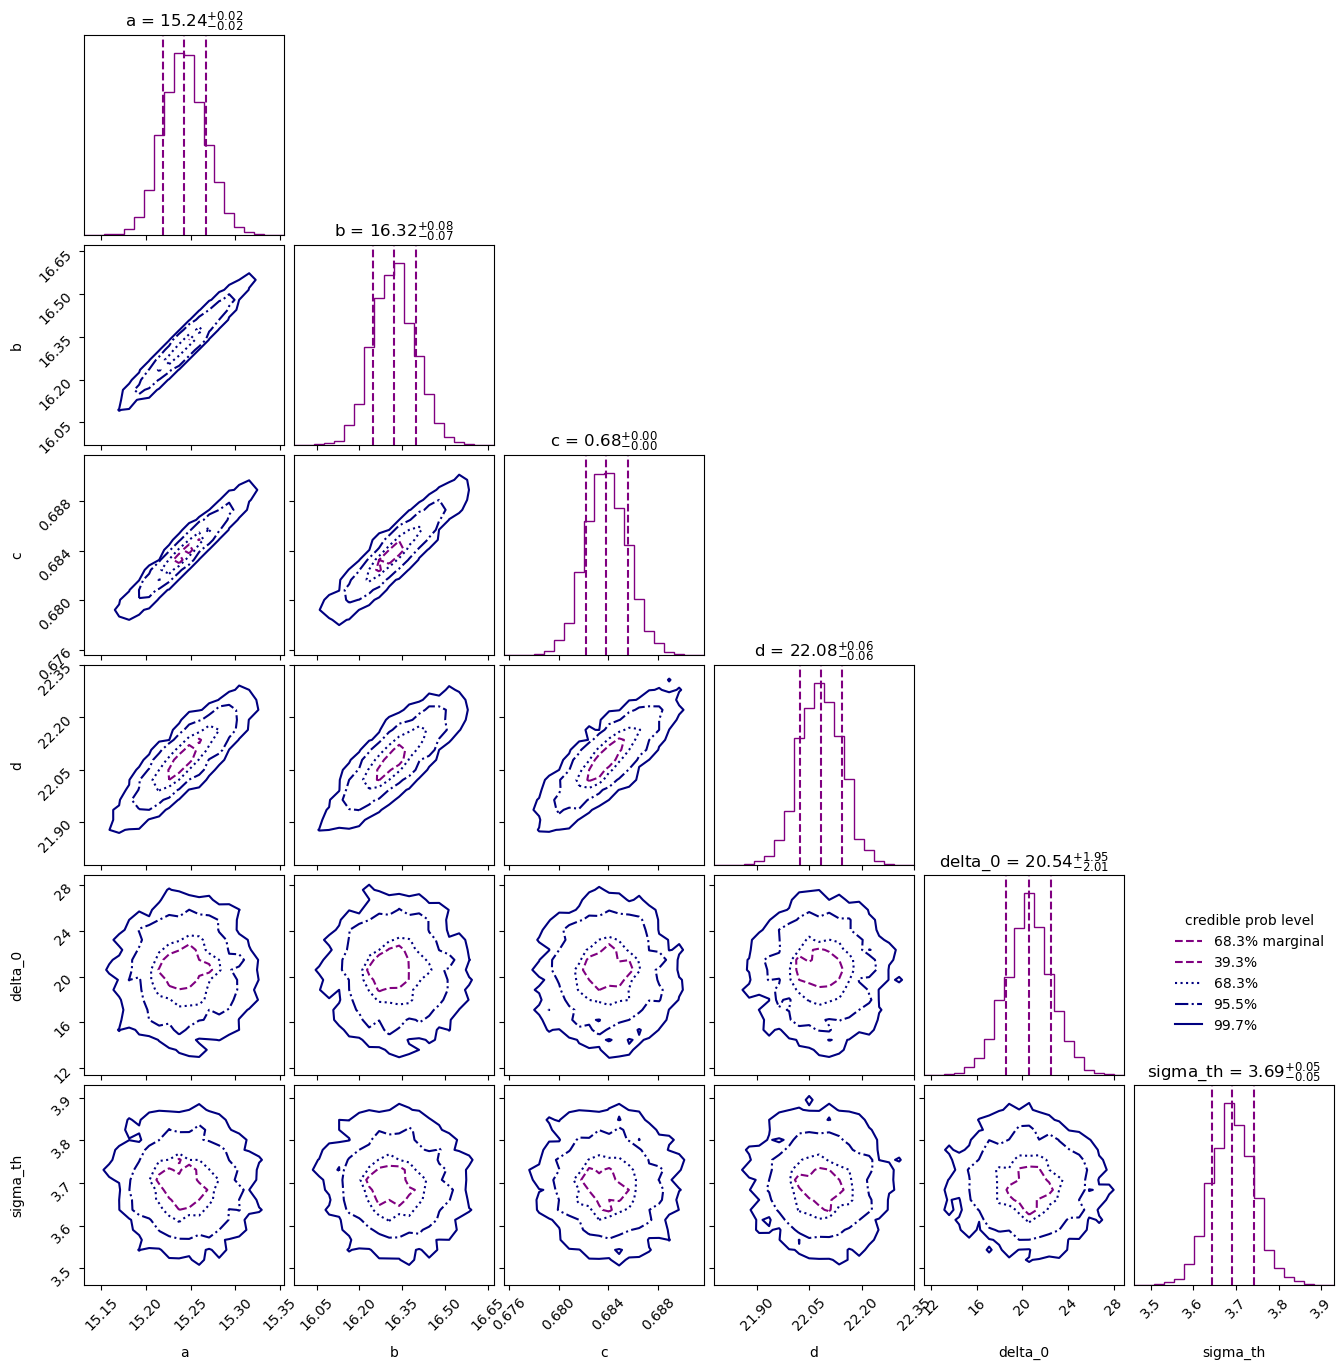

In [26]:
cornerplot_delta = sampler_delta.plot_corner()

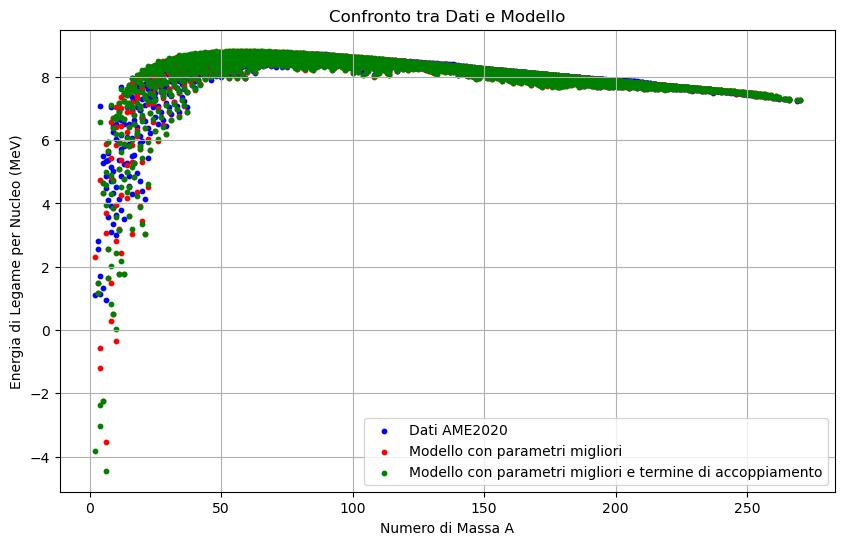

In [27]:
# calcolo il BE con i parametri migliori per ogni nucleo e confronto con i dati
a_best2, b_best2, c_best2, d_best2,  delta_0_best2, sigma_th_best2 = result_delta['posterior']['mean']
A = df['A'].values
Z = df['Z'].values
N = df['N'].values
BE_obs = (df['binding'].values /1000) # Convertiamo da KeV a MeV
BE_model1 = model(A, Z, N, a_best, b_best, c_best, d_best)/A
BE_model2 = model_delta(A, Z, N, a_best2, b_best2, c_best2, d_best2, delta_0_best2)/A   
plt.figure(figsize=(10, 6))
plt.scatter(A, BE_obs, s=10, color='blue', label='Dati AME2020')
plt.scatter(A, BE_model1, s=10, color='red', label='Modello con parametri migliori')
plt.scatter(A, BE_model2, s=10, color='green', label='Modello con parametri migliori e termine di accoppiamento')
plt.xlabel('Numero di Massa A')
plt.ylabel('Energia di Legame per Nucleo (MeV)')
plt.title('Confronto tra Dati e Modello')
plt.legend()
plt.grid()
plt.show()

In [31]:
def prior_surface(cube):
    a = 10 * cube[0] * 10 
    b = 10.0 * cube[1] * 15 
    c = cube[2] * 2 
    d =  10 * cube[3] * 25 
    delta_0 = cube[4] * 30  
    a_st = 10 + cube[5] * 30
    sigma_th = cube[6] * 10
    
    return [a, b, c, d, delta_0, a_st, sigma_th]

def model__surface(A, Z, N, a, b, c, d, delta_0, a_st):
    delta = np.zeros_like(A, dtype=float)
    
    # Maschere booleane per pari-pari e dispari-dispari
    pari_pari = (N % 2 == 0) & (Z % 2 == 0)
    dispari_dispari = (N % 2 == 1) & (Z % 2 == 1)
    pari_dispari = (N%2 ==0) & (Z%2 == 1) | (N%2 == 1) & (Z%2 == 0)
    
    # Calcolo massivo
    delta_term = delta_0 / A**(3/4)
    
    # Assegnazione
    delta[pari_pari] = delta_term[pari_pari]
    delta[dispari_dispari] = -delta_term[dispari_dispari]
    delta[pari_dispari] = 0
    
    return a * A - b * A**(2/3) - c*(Z* (Z - 1) / (A**(1/3))) - d * (N-Z)**2 / A + delta + a_st*(N-Z)**2 / A**(4/3)

def log_likelihood_surface(params):
    a, b, c, d, delta_0, a_st, sigma_th = params
    A = df['A'].values
    Z = df['Z'].values
    N = df['N'].values
    BE_obs = (df['binding'].values /1000)*A  # Convertiamo da KeV a MeV
    BE_model = model__surface(A, Z, N, a, b, c, d, delta_0, a_st)
    sigma_exp = (df['binding_unc'].values / 1000) * A  # in MeV
    sigma_tot = np.sqrt(sigma_exp**2 + sigma_th**2)
    
    # Log-likelihood usando l'incertezza totale
    logL = -0.5 * np.sum(((BE_obs - BE_model) / sigma_tot)**2 + np.log(2 * np.pi * sigma_tot**2))
    return logL

In [32]:
#run ultranest
sampler_surface = ultranest.ReactiveNestedSampler(['a', 'b', 'c', 'd',  'delta_0', 'a_st', 'sigma_th'], log_likelihood_surface, prior_surface)
result_surface = sampler_surface.run(min_num_live_points=400, dKL=np.inf, min_ess=100)
print(result_surface)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-6e+03  296.35 [-6299.5290..-6299.5289]*| it/evals=16650/81344 eff=20.5698% N=400     0  0    0  
[ultranest] Likelihood function evaluations: 81344
[ultranest]   logZ = -6340 +- 0.2202
[ultranest] Effective samples strategy satisfied (ESS = 495.5, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.18 to 0.54, need <0.5)
[ultranest]   logZ error budget: single: 0.31 bs:0.22 tail:0.50 total:0.55 required:<0.50
[ultranest] done iterating.
{'niter': 17051, 'logz': np.float64(-6339.737884283997), 'logzerr': np.float64(0.6372732415301008), 'logz_bs': np.float64(-6339.7772693135585), 'logz_single': np.float64(-6339.737884283997), 'logzerr_tail': np.float64(0.5031249218036464), 'logzerr_bs': np.float64(0.39112977057538956), 'ess': np.float64(495.54223246128925), 'H': np.float64(39.66962010825682), 'Herr': np.float64(0.2050873184

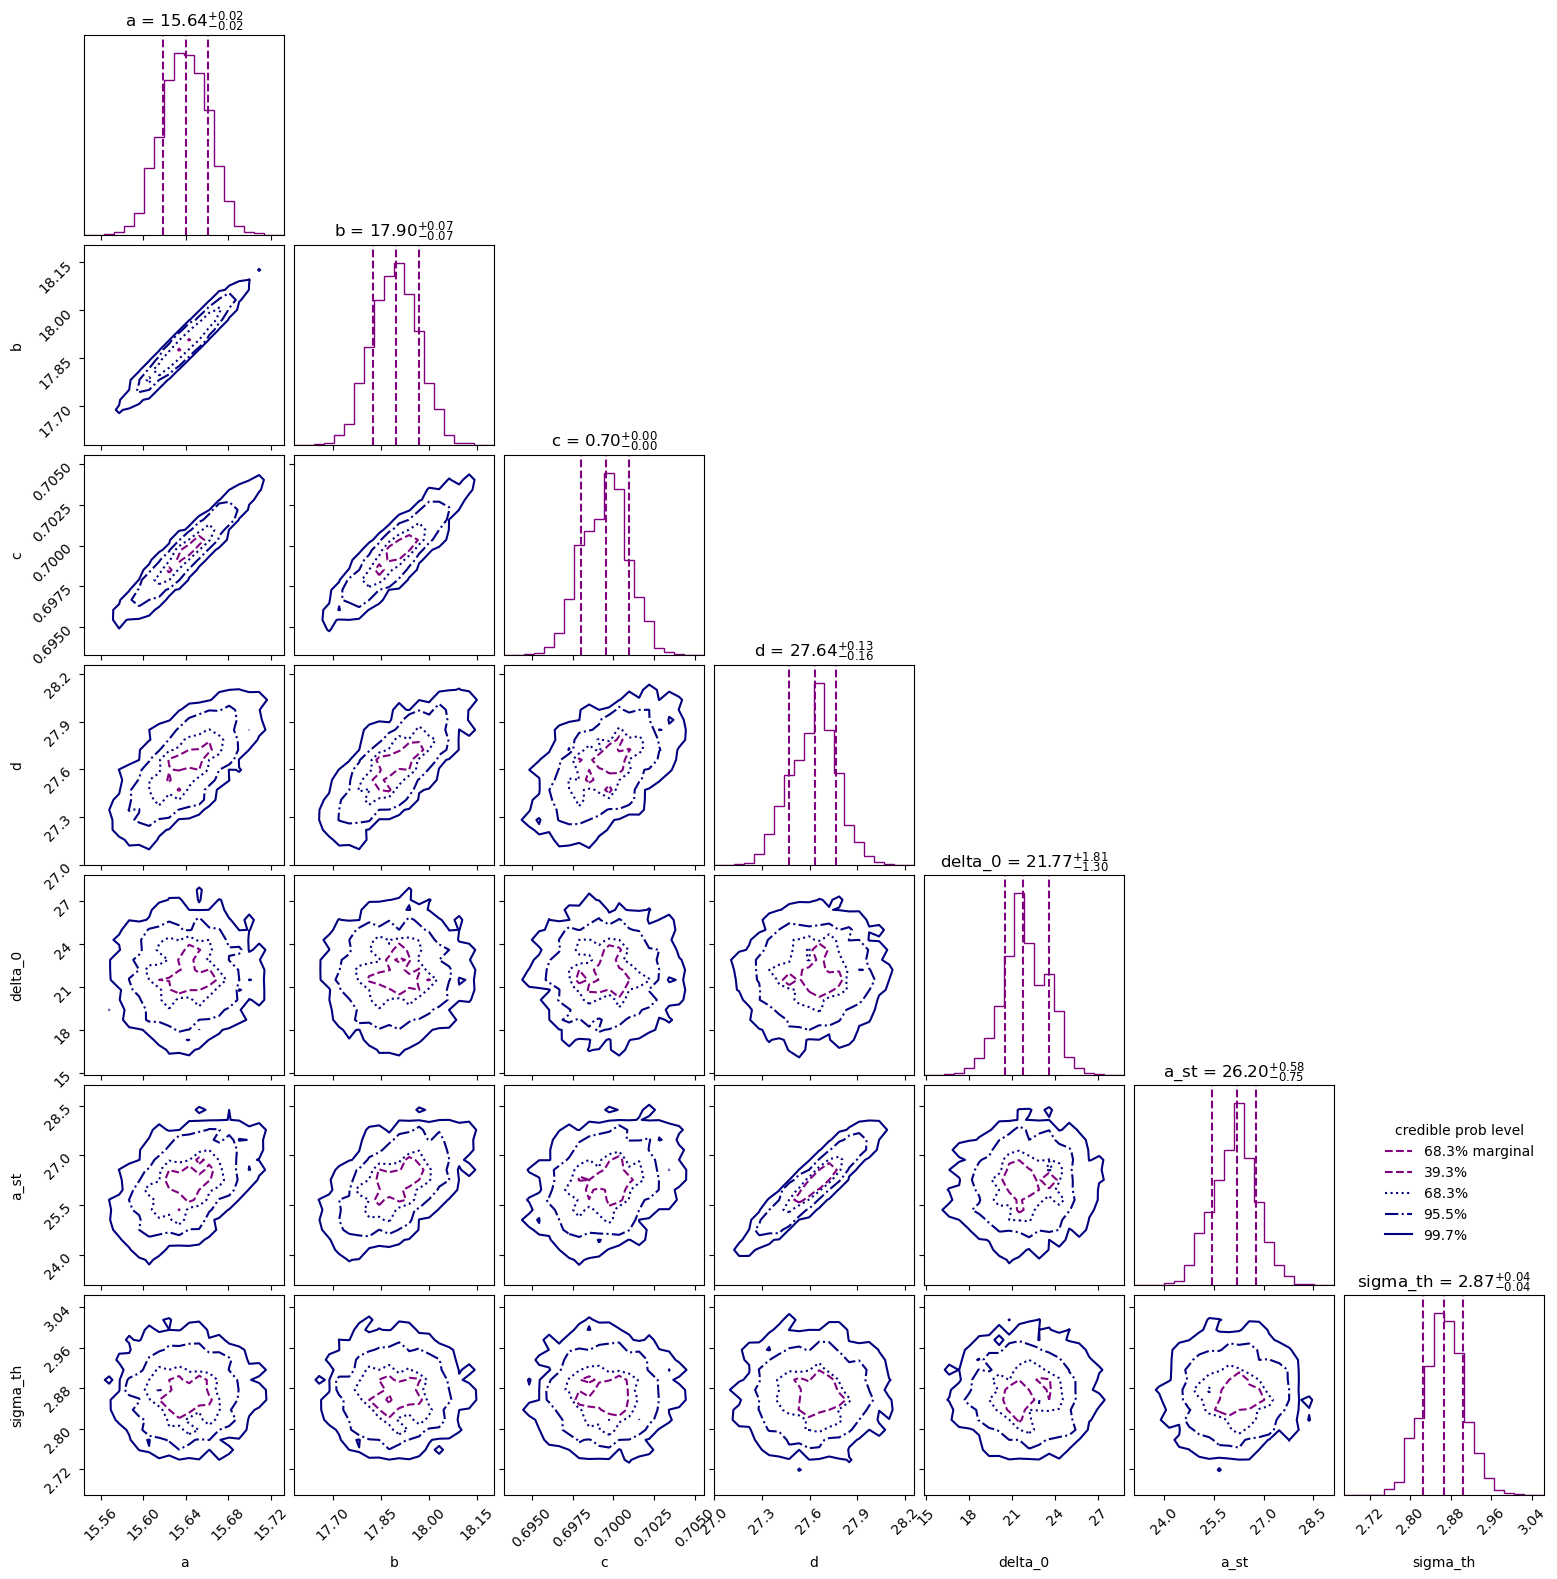

In [33]:
cornerplot_surface = sampler_surface.plot_corner()

In [43]:
def prior_wigner(cube):
    a = 10 * cube[0] * 10 
    b = 10.0 * cube[1] * 15 
    c = cube[2] * 2 
    d =  10 * cube[3] * 25 
    delta_0 = cube[4] * 30  
    a_w = cube[5] * (-50) + 40 #da 
    sigma_th = cube[6] * 10
    
    return [a, b, c, d, delta_0, a_w, sigma_th]

def model_wigner(A, Z, N, a, b, c, d, delta_0, a_w):
    delta = np.zeros_like(A, dtype=float)
    
    # Maschere booleane per pari-pari e dispari-dispari
    pari_pari = (N % 2 == 0) & (Z % 2 == 0)
    dispari_dispari = (N % 2 == 1) & (Z % 2 == 1)
    pari_dispari = (N%2 ==0) & (Z%2 == 1) | (N%2 == 1) & (Z%2 == 0)
    
    # Calcolo massivo
    delta_term = delta_0 / A**(3/4)
    
    # Assegnazione
    delta[pari_pari] = delta_term[pari_pari]
    delta[dispari_dispari] = -delta_term[dispari_dispari]
    delta[pari_dispari] = 0
    
    return a * A - b * A**(2/3) - c*(Z* (Z - 1) / (A**(1/3))) - d * (N-Z)**2 / A + delta + a_w *np.abs(N-Z)/A

def log_likelihood_wigner(params):
    a, b, c, d, delta_0, a_w, sigma_th = params
    A = df['A'].values
    Z = df['Z'].values
    N = df['N'].values
    BE_obs = (df['binding'].values /1000)*A  # Convertiamo da KeV a MeV
    BE_model = model_wigner(A, Z, N, a, b, c, d, delta_0, a_w)
    sigma_exp = (df['binding_unc'].values / 1000) * A  # in MeV
    sigma_tot = np.sqrt(sigma_exp**2 + sigma_th**2)
    
    # Log-likelihood usando l'incertezza totale
    logL = -0.5 * np.sum(((BE_obs - BE_model) / sigma_tot)**2 + np.log(2 * np.pi * sigma_tot**2))
    return logL

In [44]:
#run ultranest
sampler_wigner = ultranest.ReactiveNestedSampler(['a', 'b', 'c', 'd',  'delta_0', 'a_w', 'sigma_th'], log_likelihood_wigner, prior_wigner)
result_wigner = sampler_wigner.run(min_num_live_points=300, dKL=np.inf, min_ess=100)
print(result_wigner)

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-7e+03  635.75 [-6638.0749..-6638.0745]*| it/evals=12594/66449 eff=19.0388% N=300        0     
[ultranest] Likelihood function evaluations: 66456
[ultranest]   logZ = -6678 +- 0.2727
[ultranest] Effective samples strategy satisfied (ESS = 853.4, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 298 minimum live points (dlogz from 0.20 to 0.81, need <0.5)
[ultranest]   logZ error budget: single: 0.36 bs:0.27 tail:0.35 total:0.44 required:<0.50
[ultranest] done iterating.
{'niter': 12897, 'logz': np.float64(-6678.412120115402), 'logzerr': np.float64(0.6600169047000765), 'logz_bs': np.float64(-6678.448078912199), 'logz_single': np.float64(-6678.412120115402), 'logzerr_tail': np.float64(0.3498052030781764), 'logzerr_bs': np.float64(0.559695126286897), 'ess': np.float64(853.3940468007908), 'H': np.float64(39.083283691927136), 'Herr': np.float64(0.256827995696106

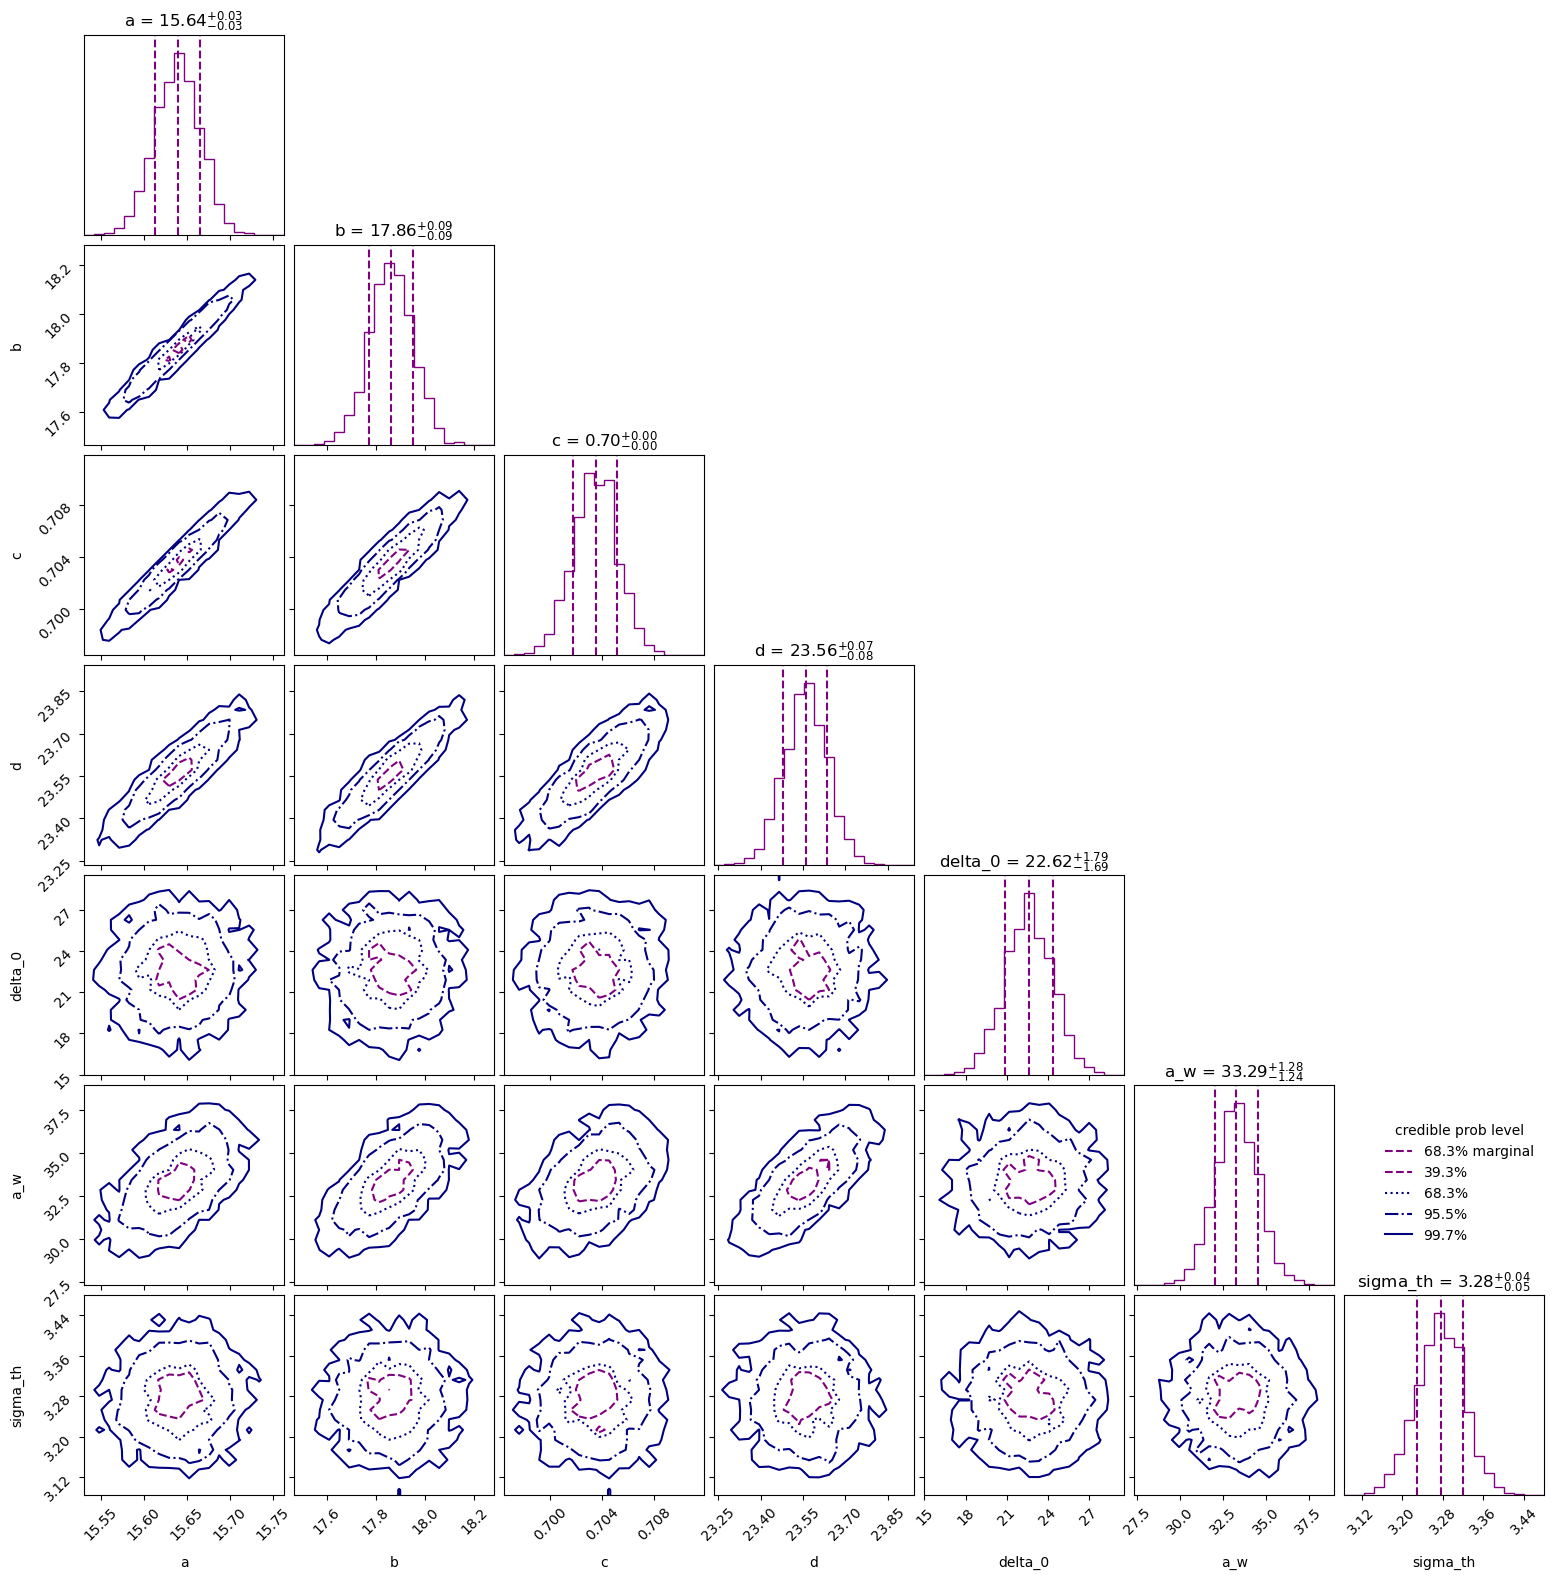

In [45]:
cornerplot_wigner = sampler_wigner.plot_corner()

In [46]:
def prior_tot(cube):
    a = 10 * cube[0] * 10 
    b = 10.0 * cube[1] * 15 
    c = cube[2] * 2 
    d =  10 * cube[3] * 25 
    delta_0 = cube[4] * 30  
    a_st = 10 + cube[5] * 40
    a_w = cube[6] * (-70)
    sigma_th = cube[7] * 10
    
    return [a, b, c, d, delta_0, a_st, a_w, sigma_th]

def model_tot(A, Z, N, a, b, c, d, delta_0, a_st, a_w):
    delta = np.zeros_like(A, dtype=float)
    
    # Maschere booleane per pari-pari e dispari-dispari
    pari_pari = (N % 2 == 0) & (Z % 2 == 0)
    dispari_dispari = (N % 2 == 1) & (Z % 2 == 1)
    pari_dispari = (N%2 ==0) & (Z%2 == 1) | (N%2 == 1) & (Z%2 == 0)
    
    # Calcolo massivo
    delta_term = delta_0 / A**(3/4)
    
    # Assegnazione
    delta[pari_pari] = delta_term[pari_pari]
    delta[dispari_dispari] = -delta_term[dispari_dispari]
    delta[pari_dispari] = 0
    
    return a * A - b * A**(2/3) - c*(Z* (Z - 1) / (A**(1/3))) - d * (N-Z)**2 / A + delta + a_w *np.abs(N-Z)/A + a_st*(N-Z)**2 / A**(4/3)

def log_likelihood_tot(params):
    a, b, c, d, delta_0, a_st, a_w, sigma_th = params
    A = df['A'].values
    Z = df['Z'].values
    N = df['N'].values
    BE_obs = (df['binding'].values /1000)*A  # Convertiamo da KeV a MeV
    BE_model = model_tot(A, Z, N, a, b, c, d, delta_0, a_st, a_w)
    sigma_exp = (df['binding_unc'].values / 1000) * A  # in MeV
    sigma_tot = np.sqrt(sigma_exp**2 + sigma_th**2)
    
    # Log-likelihood usando l'incertezza totale
    logL = -0.5 * np.sum(((BE_obs - BE_model) / sigma_tot)**2 + np.log(2 * np.pi * sigma_tot**2))
    return logL

In [47]:
#run ultranest
sampler_tot = ultranest.ReactiveNestedSampler(['a', 'b', 'c', 'd',  'delta_0', 'a_st', 'a_w', 'sigma_th'], log_likelihood_tot, prior_tot)
result_tot = sampler_tot.run(min_num_live_points=300, dKL=np.inf, min_ess=100)
print(result_tot)

[ultranest] Sampling 300 live points from prior ...


/home/ele/anaconda3/lib/python3.13/site-packages/ultranest/integrator.py:1903: UserWarning: Sampling from region seems inefficient (0/40 accepted in iteration 2500). To improve efficiency, modify the transformation so that the current live points are ellipsoidal, or use a stepsampler, or set frac_remain to a lower number (e.g., 0.5) to terminate earlier.
  u, v, logl, nc, quality = self._refill_samples(Lmin, ndraw, nit)


[ultranest] Explored until L=-6e+03  226.41 [-6227.1212..-6227.1200]*| it/evals=15412/679460 eff=2.2693% N=300 
[ultranest] Likelihood function evaluations: 679460
[ultranest]   logZ = -6274 +- 0.3042
[ultranest] Effective samples strategy satisfied (ESS = 2235.5, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.48+-0.09 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 298 minimum live points (dlogz from 0.25 to 0.70, need <0.5)
[ultranest]   logZ error budget: single: 0.38 bs:0.30 tail:0.01 total:0.30 required:<0.50
[ultranest] done iterating.
{'niter': 15713, 'logz': np.float64(-6273.711035743477), 'logzerr': np.float64(0.698713827733594), 'logz_bs': np.float64(-6273.663930926951), 'logz_single': np.float64(-6273.711035743477), 'logzerr_tail': np.float64(0.009930139983225672), 'logzerr_bs': np.float64(0.6986432604599031), 'ess': np.float64(2235.4596636635974), 'H': np.float64(43.2286876754406), 'Herr': np.float64(0.26451881564119634), 'post

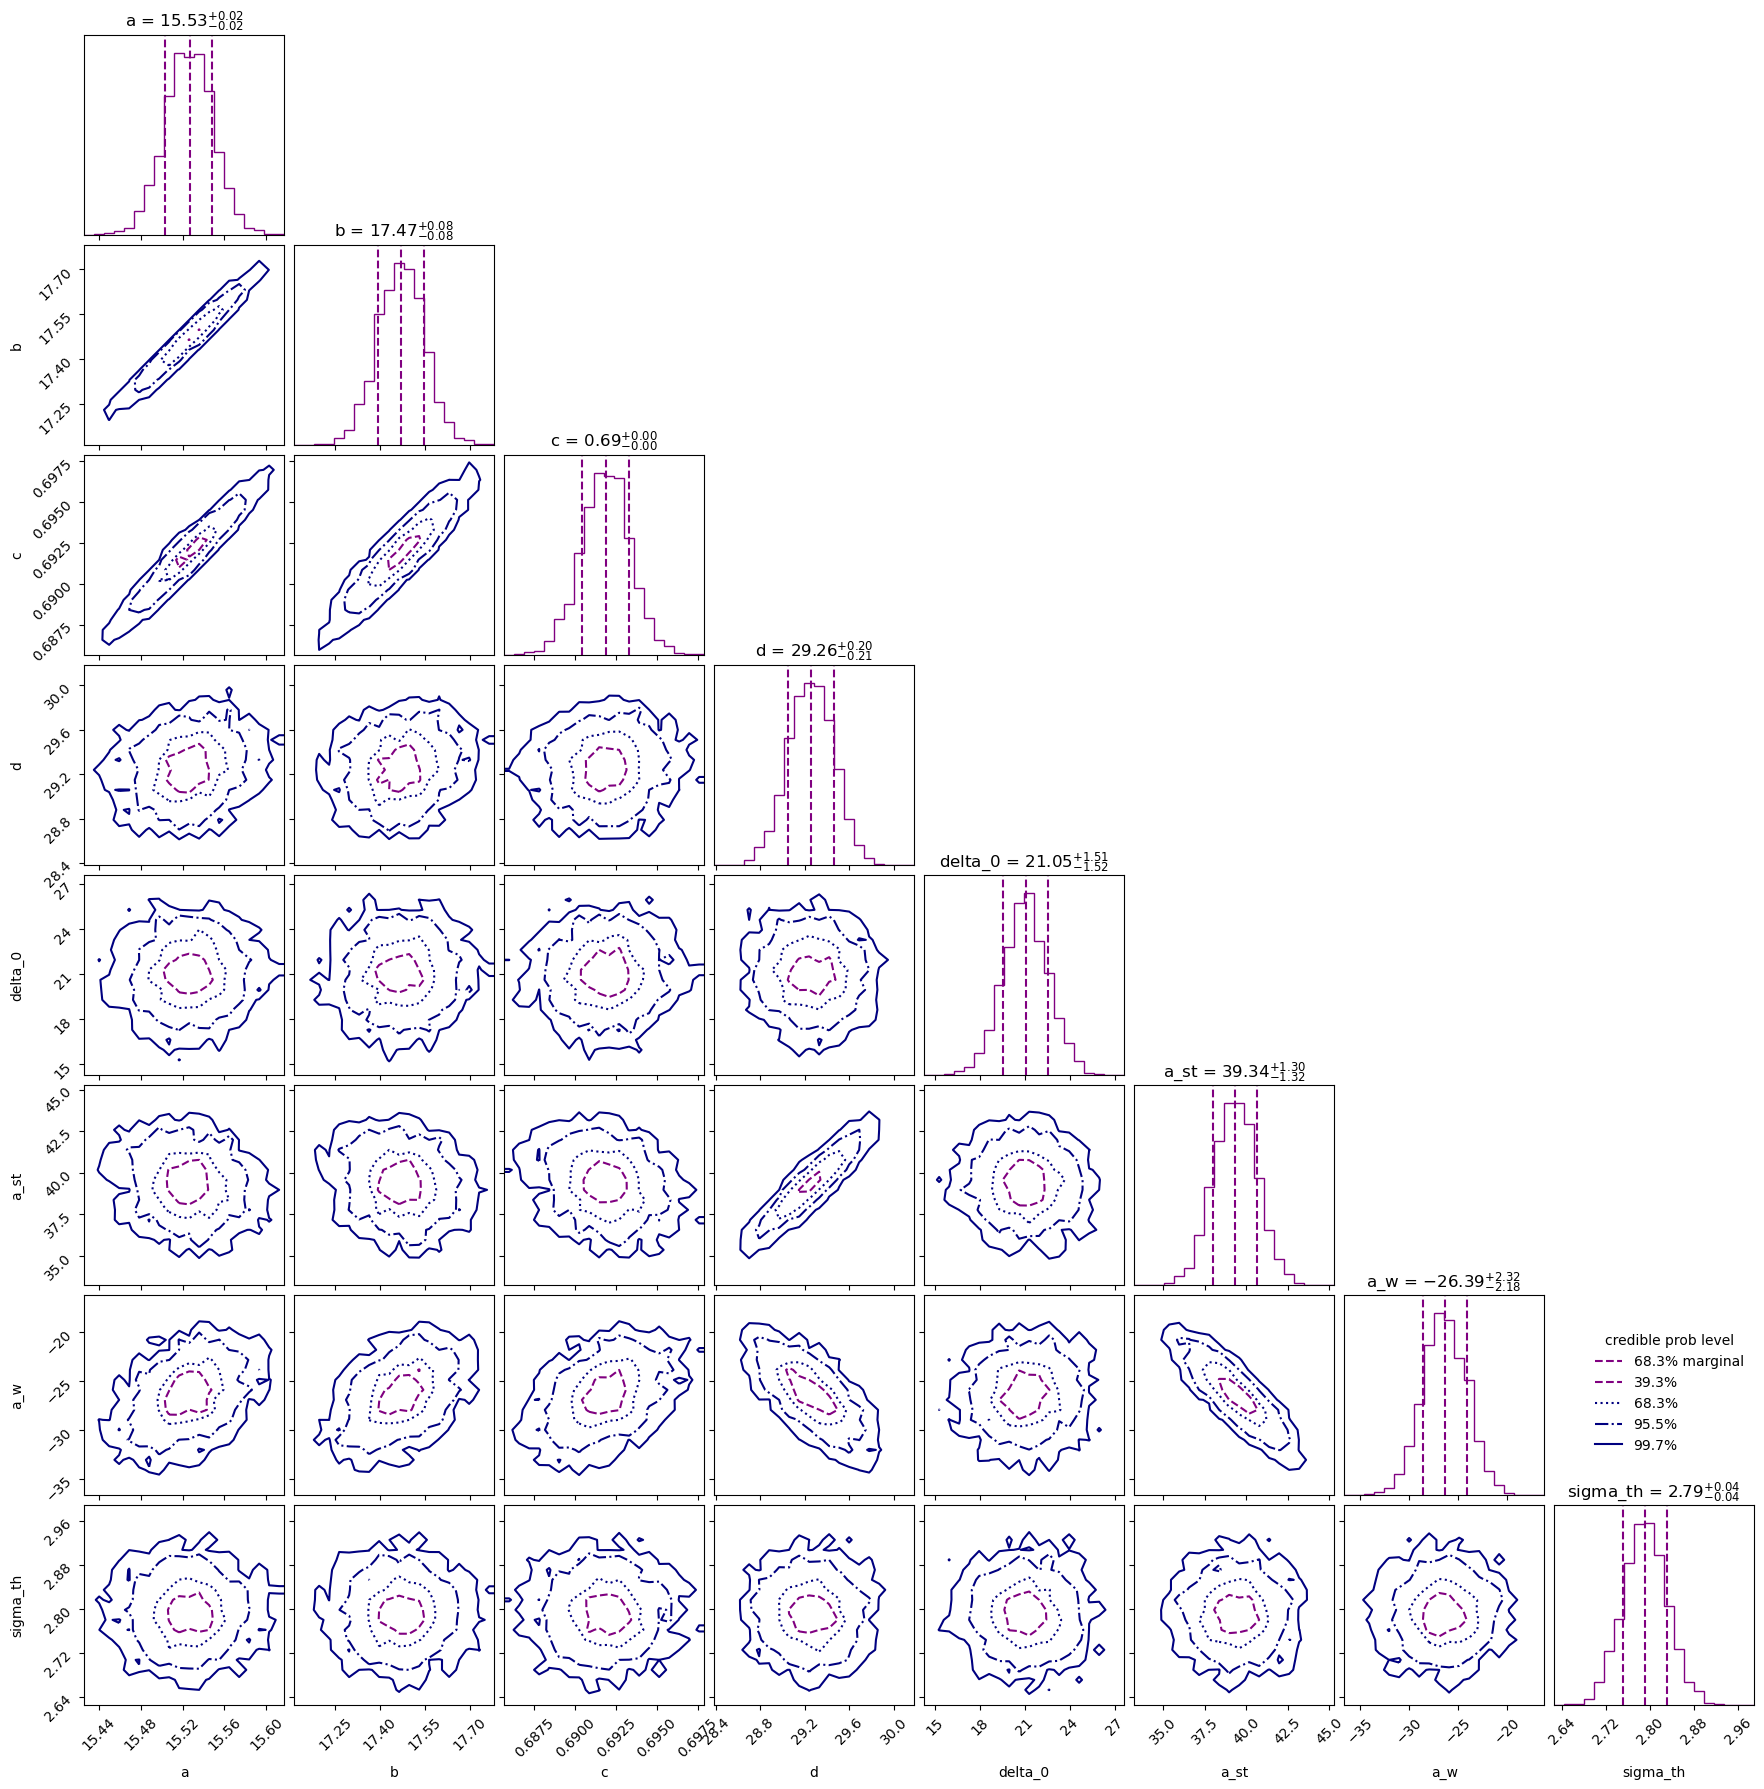

In [48]:
cornerplot_tot = sampler_tot.plot_corner()

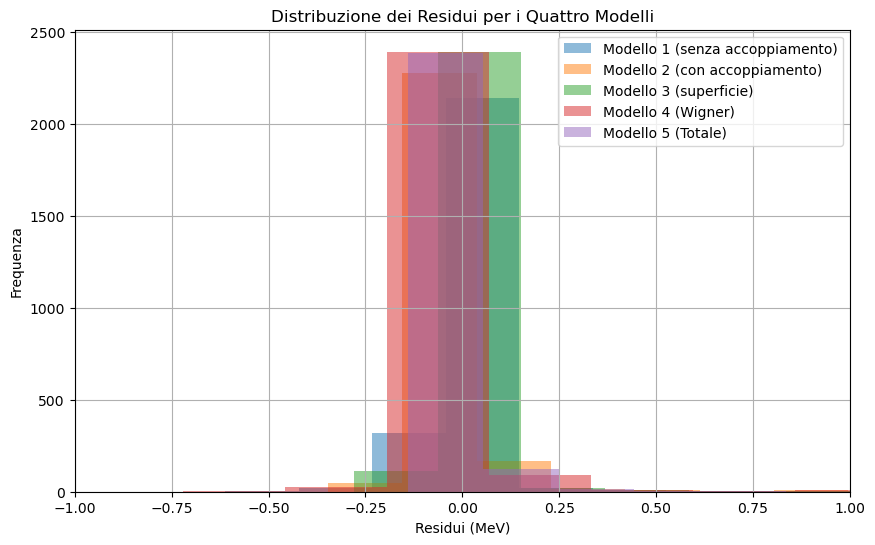

In [50]:
# confronto tra i modelli
a_best, b_best, c_best, d_best, sigma_th_best = result['posterior']['mean']
BE_model = model(A, Z, N, a_best, b_best, c_best, d_best)/A  
a2_best2, b_best2, c_best2, d_best2,  delta_0_best2, sigma_th_best2 = result_delta['posterior']['mean']
BE_model_delta = model_delta(A, Z, N, a_best2, b_best2, c_best2, d_best2, delta_0_best2)/A
a_best3, b_best3, c_best3, d_best3,  delta_0_best3, a_st_best3, sigma_th_best3 = result_surface['posterior']['mean']
BE_model_surface = model__surface(A, Z, N, a_best3, b_best3, c_best3, d_best3, delta_0_best3, a_st_best3)/A
a_best4, b_best4, c_best4, d_best4,  delta_0_best4, a_w_best4, sigma_th_best4 = result_wigner['posterior']['mean']
BE_model_wigner = model_wigner(A, Z, N, a_best4, b_best4, c_best4, d_best4, delta_0_best4, a_w_best4)/A   
a_best_tot, b_best_tot, c_best_tot, d_best_tot,  delta_0_best_tot, a_st_best_tot, a_w_best_tot, sigma_th_best_tot = result_tot['posterior']['mean']
BE_model_tot = model_tot(A, Z, N, a_best_tot, b_best_tot, c_best_tot, d_best_tot, delta_0_best_tot, a_st_best_tot, a_w_best_tot)/A

residui_model = BE_obs - BE_model
residui_model_delta = BE_obs - BE_model_delta
residui_model_surface = BE_obs - BE_model_surface
residui_model_wigner = BE_obs - BE_model_wigner
residui_model_tot = BE_obs - BE_model_tot
plt.figure(figsize=(10, 6))
plt.hist(residui_model, bins=30, alpha=0.5, label='Modello 1 (senza accoppiamento)')
plt.hist(residui_model_delta, bins=30, alpha=0.5, label='Modello 2 (con accoppiamento)')
plt.hist(residui_model_surface, bins=30, alpha=0.5, label='Modello 3 (superficie)')
plt.hist(residui_model_wigner, bins=30, alpha=0.5, label='Modello 4 (Wigner)')
plt.hist(residui_model_tot, bins=30, alpha=0.5, label='Modello 5 (Totale)')
plt.xlim(-1, 1)
plt.xlabel('Residui (MeV)')
plt.ylabel('Frequenza')
plt.title('Distribuzione dei Residui per i Quattro Modelli')
plt.legend()
plt.grid()
plt.show()

In [51]:
# confronto bayesiano tra i due modelli usando il Bayes factor
logZ1 = result['logz']
logZ2 = result_delta['logz']
logZ3 = result_surface['logz']
logZ4 = result_wigner['logz']
logZ5 = result_tot['logz']
bayes_factor_12 = logZ2 - logZ1
bayes_factor_13 = logZ3 - logZ1
bayes_factor_14 = logZ4 - logZ1
bayes_factor_15 = logZ5 - logZ1
bayes_factor_23 = logZ3 - logZ2
bayes_factor_24 = logZ4 - logZ2
bayes_factor_25 = logZ5 - logZ2
bayes_factor_34 = logZ4 - logZ3
bayes_factor_35 = logZ5 - logZ3
bayes_factor_45 = logZ5 - logZ4
print(f"Bayes Factor (Modello 2 vs Modello 1): {bayes_factor_12:.2f}")
print(f"Bayes Factor (Modello 3 vs Modello 1): {bayes_factor_13:.2f}")
print(f"Bayes Factor (Modello 4 vs Modello 1): {bayes_factor_14:.2f}")
print(f"Bayes Factor (Modello 5 vs Modello 1): {bayes_factor_15:.2f}")
print(f"Bayes Factor (Modello 3 vs Modello 2): {bayes_factor_23:.2f}")
print(f"Bayes Factor (Modello 4 vs Modello 2): {bayes_factor_24:.2f}")
print(f"Bayes Factor (Modello 5 vs Modello 2): {bayes_factor_25:.2f}")
print(f"Bayes Factor (Modello 4 vs Modello 3): {bayes_factor_34:.2f}")
print(f"Bayes Factor (Modello 5 vs Modello 3): {bayes_factor_35:.2f}")
print(f"Bayes Factor (Modello 5 vs Modello 4): {bayes_factor_45:.2f}")


Bayes Factor (Modello 2 vs Modello 1): 49.78
Bayes Factor (Modello 3 vs Modello 1): 691.56
Bayes Factor (Modello 4 vs Modello 1): 352.89
Bayes Factor (Modello 5 vs Modello 1): 757.59
Bayes Factor (Modello 3 vs Modello 2): 641.78
Bayes Factor (Modello 4 vs Modello 2): 303.11
Bayes Factor (Modello 5 vs Modello 2): 707.81
Bayes Factor (Modello 4 vs Modello 3): -338.67
Bayes Factor (Modello 5 vs Modello 3): 66.03
Bayes Factor (Modello 5 vs Modello 4): 404.70


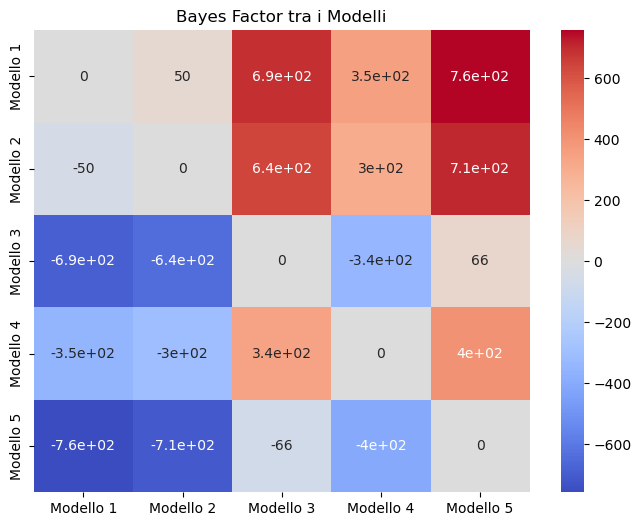

In [ ]:
# heatmapn dei fattori di Bayes per i modelli
import seaborn as sns
bayes_factors = np.array([[0, bayes_factor_12, bayes_factor_13, bayes_factor_14, bayes_factor_15],
                          [-bayes_factor_12, 0, bayes_factor_23, bayes_factor_24, bayes_factor_25],
                          [-bayes_factor_13, -bayes_factor_23, 0, bayes_factor_34, bayes_factor_35],
                          [-bayes_factor_14, -bayes_factor_24, -bayes_factor_34, 0, bayes_factor_45],
                          [-bayes_factor_15, -bayes_factor_25, -bayes_factor_35, -bayes_factor_45, 0]])
modelli = ['Modello 1', 'Modello 2', 'Modello 3', 'Modello 4', 'Modello 5']
plt.figure(figsize=(8, 6))
sns.heatmap(bayes_factors, xticklabels=modelli, yticklabels=modelli, annot=True, cmap='coolwarm', center=0)
plt.title('Bayes Factor tra i Modelli')
plt.show()

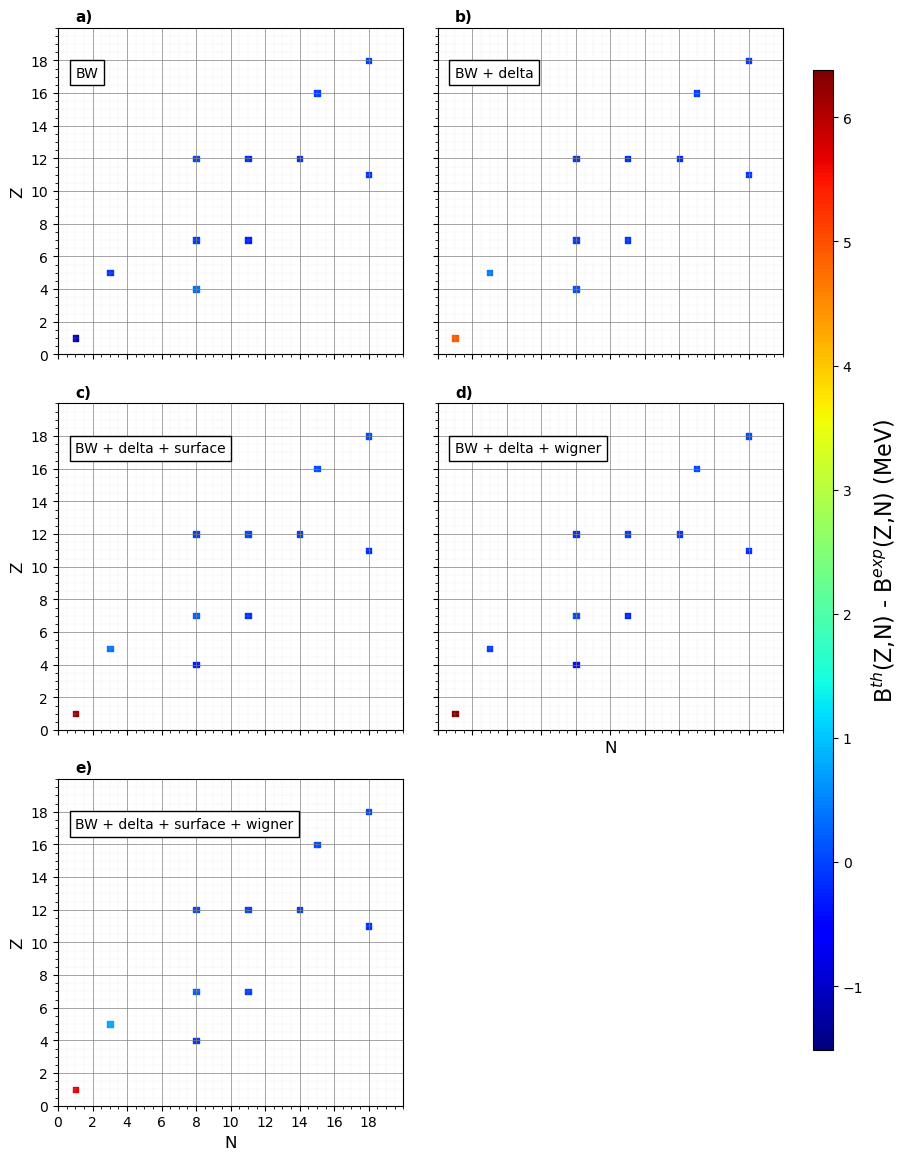

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

models = [
    "BW", "BW + delta", "BW + delta + surface", "BW + delta + wigner", "BW + delta + surface + wigner"
]
labels = ['a)', 'b)', 'c)', 'd)', 'e)']

# I tuoi residui
delta_B_modelli = [residui_model, residui_model_delta, residui_model_surface, residui_model_wigner, residui_model_tot]

# 1. CALCOLA IL MINIMO E MASSIMO GLOBALE DAI TUOI DATI
# Questo serve per avere la colorbar coerente su tutti i grafici
vmin = np.min(delta_B_modelli)
vmax = np.max(delta_B_modelli)

# 2. Crea la griglia 3x2
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 14), sharex=True, sharey=True)
fig.subplots_adjust(right=0.85, wspace=0.1, hspace=0.15)

sc = None 

# 3. Ciclo su ogni grafico della griglia
for i, ax in enumerate(axes.flat):
    
    # Se abbiamo superato il numero di modelli (es. il 6° riquadro vuoto), lo nascondiamo
    if i >= len(models):
        ax.axis('off')
        continue

    # Prendi i tuoi dati reali! (Nessun random.uniform)
    delta_B = delta_B_modelli[i]
    
    # 4. Crea il grafico (ora rimettiamo vmin e vmax!)
    sc = ax.scatter(N[::20], Z[::20], c=delta_B[::20], cmap='jet', vmin=vmin, vmax=vmax, marker='s', s=15)
    
    # 5. Aggiungi il riquadro col nome del modello
    ax.text(0.05, 0.85, models[i], transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.4'))
    
    # Lettera del pannello
    ax.text(0.05, 1.02, labels[i], transform=ax.transAxes, fontsize=11, fontweight='bold')
    
    # 6. Impostazioni assi e griglia
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 20)
    ax.set_xticks(np.arange(0, 20, 2))
    ax.set_yticks(np.arange(0, 20, 2))
    
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray')
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='lightgray')
    
    # Logica per mostrare le etichette N e Z nei punti giusti
    # Ora che nascondiamo l'ultimo grafico, l'etichetta 'N' va messa sui grafici in basso
    if i == 4 or i == 3: # Indici della riga in basso
        ax.set_xlabel('N', fontsize=12)
    if i % 2 == 0:
        ax.set_ylabel('Z', fontsize=12)

# 7. AGGIUNGI LA COLORBAR GLOBALE
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7]) 
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('B$^{th}$(Z,N) - B$^{exp}$(Z,N) (MeV)', fontsize=16)

plt.show()